# Lab Exercise: Urban Change Detection with Tessera 


### 📝 Scenario

**💼 Client:** City of Graz, Urban Monitoring and GIS Unit

**⚠️ Problem:** The city wants to monitor redevelopment areas more efficiently. Manual comparison of imagery across years is slow, and not every suspected change deserves immediate inspection.

**🎯 Your mission:** Build a reproducible notebook that uses current Overture building footprints and TESSERA annual embeddings to flag buildings with unusually high surrounding change between 2017 and 2024.

<div class="alert alert-warning">

### Important limitation

This workflow does **not** prove that a building changed.  
It creates a ranked list of **candidate buildings for manual inspection**.

</div>

---

## 🎯 Learning outcomes

---

1. Query current building footprints from Overture using DuckDB. (already introduced in the previous exercise) 
2. Understand what a TESSERA embedding is at a basic level: a compact 128-dimensional representation of a 10 m pixel for one year
3. Compute a simple pixel-level change score between two years.
4. Aggregate pixel-level change to building-level change using zonal statistics.
5. Classify candidate high-change buildings using a simple threshold.
6. Validate a small sample manually and distinguish “detected signal” from “confirmed change.”


<div class="alert alert-info">
📖 Excursion: How does Change Detection work with TESSERA?

Traditional satellite imagery usually only stores raw color values (Red, Green, Blue). TESSERA, on the other hand, is a Vision Foundation Model. It compresses the entire satellite data of a year (including seasonal dynamics like plant growth) for every 10x10m pixel into a compact 128-dimensional vector (an embedding).

To find changes between 2017 and 2024, we don't compare classic optical images. We use math in vector space: We calculate the Euclidean distance (L2-Norm) between the 2017 vector and the 2024 vector.

If the distance is small, the pixel's structure remained stable (e.g., an existing forest). If the distance is large, the underlying meaning of that pixel has shifted massively (e.g., a new building was constructed). In the next step, we will use numpy to calculate this mathematical distance and intersect it with our Overture building footprints!

</div>

---

## 1. Setup

---

```text 
💡 Good practice: keep paths, years, bounding boxes, and assumptions in one place.
```

In [ ]:
# install uv, if you don't have it already
%pip install uv

In [ ]:
# installs for the notebook, uncomment to install them if not done already, or select the library you need to install
!uv pip install numpy geotessera pathlib geopandas shapely pandas rasterio matplotlib duckdb scikit-learn leafmap

In [ ]:
import gc
import numpy as np
import leafmap
from pathlib import Path
import geopandas as gpd
from geotessera import GeoTessera
import shapely.wkt
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio import features, transform
import matplotlib.pyplot as plt
import duckdb
from sklearn.decomposition import PCA
from duckdb import df

In [ ]:
# Path setup for data and outputs
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Configuration
CONFIG = {
    # Graz Reininghaus bounding box: (min_lon, min_lat, max_lon, max_lat)
    "bbox": (15.400364, 47.057698, 15.420964, 47.068310),

    # Years to compare
    "year_past": 2017,
    "year_present": 2024,

    # Output files
    "overture_gpkg": DATA_DIR / "overture_buildings_reininghaus.gpkg",
    "overture_geojson": DATA_DIR / "overture_buildings_reininghaus.geojson",
    "overture_parquet": DATA_DIR / "overture_buildings_reininghaus.parquet",
    "candidate_buildings_gpkg": OUTPUT_DIR / "candidate_high_change_buildings.gpkg",
    "final_map_html": OUTPUT_DIR / "candidate_change_map.html",
}

CONFIG

<div class="alert alert-info">  
📖 As in the last exercise (Lab02), we will once again use Overture Maps, an open dataset created by Amazon, Meta, Microsoft, and TomTom, which contains highly accurate building footprints.

Instead of downloading gigabytes of data, we will use **DuckDB**, a fast analytical database. DuckDB allows us to write an SQL query that pulls *only* the buildings within our specific bounding box directly from Overture's cloud storage (Amazon S3), without downloading the rest of the world!
</div>

<div class="alert alert-danger">

**🚀 TODO: Fetching Overture Buildings via DuckDB**

Your task is to recreate the Overture data pipeline from Lab 02, just with the new Bounding Box. Feel free to look back at your old notebook and copy the logic!

1. Unpack the ACTIVE_BBOX coordinates.

2. Connect to DuckDB and load the spatial and httpfs extensions. Set the S3 region.

3. Complete the SQL query to select buildings from the Overture parquet file, filtering geographically by your bounding box.

4. Execute the query, parse the text geometries, and build a GeoDataFrame with the correct CRS (EPSG:4326).

Note: Overture provides a **STAC Catalog** (SpatioTemporal Asset Catalog) hosted via a JSON file. We can query this catalog with DuckDB to dynamically find the name of the newest release, store it in a variable, and build our download URL. (this will fix the version issue we had in the previous exercise)

In the `read_parquet` function, we replace the hardcoded date string with DuckDB's `getvariable()` function. Note that DuckDB uses the `||` operator to concatenate strings in SQL

`FROM read_parquet('s3://overturemaps-us-west-2/release/' || getvariable('latest') || '/theme=...`

- 📚 [overture documentation](https://docs.overturemaps.org/getting-data/)
- 📚 [overture buildings documentation](https://docs.overturemaps.org/schema/reference/buildings/building/)
- 📚 [overture stac](https://stac.overturemaps.org/catalog.json)


</div>

In [ ]:
# Fetch Building Footprints (Overture Maps)
# SKELETON CODE

# TODO: Fetch building footprints for the defined bounding box and time range using DuckDB and Overture Maps.


print("Fetching building footprints from Overture Maps via DuckDB...")

# 1. Unpack the bounding box
# TODO: Extract the individual coordinates from your Bounding Box
min_lon, min_lat, max_lon, max_lat = CHANGEME

# 2. Database Connection & Extensions
# TODO: Connect to DuckDB and execute the commands to load 'spatial' and 'httpfs', and set the s3_region
# con.execute(...)
# con.execute(...)
# con.execute(...)

# 3. Fetch the newest release version dynamically
# TODO open the url in your browser to see what information is present in the JSON
con.execute("SET VARIABLE latest = (SELECT latest FROM 'https://stac.overturemaps.org/catalog.json');")

# 4. The SQL Query
# TODO: Complete the SQL query. Look at the Overture documentation or your Lab 02 code for the correct S3 path and theme/type!
# FROM read_parquet('s3://overturemaps-us-west-2/release/' || getvariable('latest') || '/theme=...
query = CHANGEME

# 5. Execute and Process
# TODO: Execute the query and convert it to a pandas DataFrame
df_overture = CHANGEME



In [ ]:
# Convert the WKT string back into shapely geometry objects
df_overture['geometry'] = df_overture['geometry'].apply(shapely.wkt.loads)

# 6. Build the GeoDataFrame
gdf_buildings = gpd.GeoDataFrame(df_overture, geometry='geometry', crs="EPSG:4326")
print(f"Loaded {len(gdf_buildings)} buildings.")

In [ ]:
overture_file = DATA_DIR / "overture_buildings_reininghaus.gpkg"
gdf_buildings.to_file(overture_file, driver="GPKG")

---

## 3. Visual Validation (Overture Maps)

---


<div class="alert alert-info">

📖 Before we proceed with our analysis, we must validate our raw data. A common mistake in spatial pipelines is fetching data for the wrong coordinates, mixing up latitude/longitude, or messing up the projection.

We will use Leafmap to quickly render our Overture building footprints over a cloud-hosted satellite basemap. This acts as our visual sanity check: do our downloaded vector polygons actually align with the real-world buildings in Graz?

</div>

<div class="alert alert-danger">

**🚀 TODO: Visualizing the Ground Truth**

Your task is to plot the gdf_buildings GeoDataFrame on an interactive map using Leafmap. You can once again use the code from the last Lab!

1. Find the Center: Calculate the center latitude and longitude from your ACTIVE_BBOX to tell the map camera where to look.

2. Initialize: Create a leafmap.Map centered on those coordinates.

3. Set the Basemap: Add a satellite basemap so we can see the real world underneath the polygons.

4. Overlay Data: Use the appropriate Leafmap method to add your GeoDataFrame to the map. Pick a highly visible color (like bright yellow or red) so it stands out against the dark satellite imagery.

</div>

In [ ]:
# Visual Validation of Overture Data
# SKELETON CODE

overture_file = DATA_DIR / "overture_buildings_reininghaus.gpkg"
gdf_buildings = gpd.read_file(overture_file)

# 1. Calculate the Center
# TODO: Calculate the average of min and max coordinates to find the center
# min_lon, min_lat, max_lon, max_lat = ACTIVE_BBOX
center_lat = CHANGEME
center_lon = CHANGEME

# 2. Initialize the map camera
# TODO: Initialize leafmap.Map with the calculated center and a zoom level of 16
m = CHANGEME

# 3. Add a global satellite basemap
# TODO: Add the "SATELLITE" basemap to your map instance
# m.add_basemap(...)
CHANGEME

# 4. Add the Overture buildings
# TODO: Add your gdf_buildings to the map. Give it a layer name and a bright fill color
# m.add_gdf(...)
CHANGEME

# Display the map
m

<div class="alert alert-success"> 

**🧠 Questions**: 
- Critical Reflection of the data we see? Overture seems to be more up-to-date than the basemap imagery
- Why is visual validation useful even if the code runs without errors?
- Why should we call this a **reference layer** rather than ground truth?

---

## 4. TESSERA Fetching embeddings for two years

---


<div class="alert alert-info">

📖 We have our building footprints. Now we need the satellite data to see what has changed. Instead of downloading raw RGB imagery, we are pulling from TESSERA, a Vision Foundation Model.

The TESSERA global dataset is divided into a grid of tiles (roughly 10x10km). Because our bounding box for Graz is relatively small, we don't need to stream a massive mosaic. We simply calculate the center point of our bounding box and ask the API to download the single grid tile that contains this point.

This will give us the 128-dimensional embedding tensors for our area for the years 2016 and 2024.

</div>

<div class="alert alert-danger">

**🚀 TODO: Fetching the Tensors**

Your task is to initialize the GeoTessera client and download the embedding tensors for both years.

1. Initialize the Client: Set up the GeoTessera client so we can communicate with the API.
2. Find the Center: Calculate center_lat and center_lon from the unpacked ACTIVE_BBOX variable.
3. Fetch 2017 Data: Read Step 3 ("Fetch a single embedding tile") in the GeoTessera Quick Start Documentation. Use the center coordinates and the year 2017.
    
    Hint: The function returns a tuple of three things. Unpack them into variables with a suiting suffix (e.g., tensor_past, crs_past, transform_past).

    Print the shape, data type, and CRS of the returned tensor.
4. Fetch 2024 Data: Do the exact same for 2024 (only with a different suffix). Print the properties to verify they match the 2017 data!


- 📚 [tessera documentation](https://geotessera.readthedocs.io/en/latest/quickstart.html)

</div>

<div class="alert alert-info">

💡 Python Tips: Unpacking Tuples

When a Python function returns multiple values, it usually returns them as a tuple. You can "unpack" this tuple directly into separate variables in a single line.


If a function get_image_info() returns (image_data, width, height)

img, w, h = get_image_info() unpacks the tuple into three seperate variables

Pay close attention to the geotessera documentation to see exactly what fetch_embedding() returns!

</div>

In [ ]:
# TESSERA Fetching
# SKELETON CODE

#TODO: Initialize the GeoTessera client
gt_client = CHANGEME

#TODO: Calculate the center point of our bounding box to fetch the correct 10x10km tile
min_lon, min_lat, max_lon, max_lat = ACTIVE_BBOX
center_lat = CHANGEME
center_lon = CHANGEME

#TODO: Fetch a single tensor from TESSERA for the center point and the year 2017, and print out its properties (shape, data type, CRS)
CHANGEME = gt_client.fetch_embedding(CHANGEME)

#TODO: Fetch a single tensor from TESSERA for the center point and the year 2024, and print out its properties (shape, data type, CRS)
CHANGEME = gt_client.fetch_embedding(CHANGEME)


<div class="alert alert-info">

📖 **What exactly did we just download? (The 3D Tensor)**

Look at the shape of the data we just downloaded: `(1116, 766, 128)`. This is a **3D Tensor** (a multi-dimensional array). Let's break down what these numbers mean:

* **Height (1116) & Width (766):** These are the spatial dimensions. Our map of Graz Reininghaus is represented by a grid of 1116 by 766 pixels. Each pixel represents a 10x10 meter area on the ground.
* **Channels/Depth (128):** This is the magic of the Foundation Model. 

**RGB Analogy:**
If you download a standard satellite photo, the shape would be `(1116, 766, 3)`. For every pixel on the ground, you get an array of 3 numbers representing visible light: **[Red, Green, Blue]**. 

TESSERA replaces the 3 RGB channels with **128 latent dimensions**. For every single pixel, the AI provides an array of 128 floating-point numbers. We can't see them as colors, but these numbers encode deep semantic meaning. One dimension might track "vegetation health", another might track "building density", and another might track "surface temperature". We don't know exactly what each of the 128 dimensions means (it's a black box), but mathematically, they form a "fingerprint" of that 10x10m area!
</div>

<div class="alert alert-success"> 

**🧠 Questions**: 
- What information is compressed when a full year of satellite observations becomes one 128-dimensional vector?
- Why might a 10 m pixel be problematic for small buildings?
- What kinds of urban change are likely to be visible at this resolution?
- What kinds of change are likely to be missed?

---

## 4. Calculating Change (L2-Norm)

---


<div class="alert alert-info">
📖 We now have two massive tensors in our RAM. For every single 10x10m pixel on the ground, we have 128 features for the year 2017, and 128 features for the year 2024.

How do we measure "change"? We calculate the mathematical distance between these two 128-dimensional states. We use the Euclidean Distance (also known as the L2 Norm).

In 2D space (Pythagorean theorem):

d = sqrt((x2 - x1)^2 + (y2 - y1)^2)

In 128D space:

d = sqrt(sum_{i=1..128} (Feature_2024[i] - Feature_2017[i])^2)

    A small distance score (~0): The pixel's "fingerprint" is identical. Nothing changed.

    A massive distance score: The fundamental meaning of this pixel changed (e.g., a forest was cleared to build a warehouse).

Crucial Engineering Note: Squaring numbers uses a lot of memory. To prevent integer overflows, we explicitly convert our tensors to float32 before doing the math!

</div>

<div class="alert alert-danger">

**🚀 TODO: Compute Pixel-Wise Change Detection**

Your task is to calculate the Euclidean distance between the two years.

1. Type Casting: Convert both embedding_past and tensor_present to 32-bit floats (np.float32) using the .astype() method.

2. The Math: Use the np.linalg.norm() function. You need to subtract the past tensor from the present tensor. Crucial: You must set the axis parameter to -1. This tells Numpy to calculate the distance across the last dimension (the 128 channels), not across the geographic width/height!

3. Data Cleaning: Real-world data is messy. Use np.nan_to_num() to replace any NaN (Not a Number) values in your resulting map with 0.0 so they don't break our visualizations later.

</div>

<div class="alert alert-info">

💡 Numpy Tips: Tensor Math

When working with multi-dimensional arrays, standard math operations can sometimes behave unexpectedly if you don't specify the dimensions!

The Axis Parameter: If you have an image tensor of shape (1000, 1000, 128) and you want to calculate the distance of the 128 channels for each pixel individually, you must tell numpy to compute along the last dimension. In numpy, the last dimension is always axis=-1.

Handling Infinity & NaNs: Real-world data matrices often contain holes or divide-by-zero errors resulting in NaN (Not a Number). If you do math with a NaN, the result is always NaN. You can use np.nan_to_num(your_array, nan=0.0) to instantly replace all broken values with zeros.

</div>

In [ ]:
# Change Detection in TESSERA
# SKELETON CODE

# 1. Clean up RAM before heavy calculations
gc.collect()

print("\nCalculating Euclidean distance in the 128D latent space...")

# 2. Convert to float32 to prevent numerical overflows
# TODO: Use .astype() to convert both tensors
embedding_past_f32 = CHANGEME
embedding_present_f32 = CHANGEME

# 3. Calculate Euclidean Distance (L2 Norm)
# TODO: Use np.linalg.norm to calculate the distance between the two tensors. 
# Remember to subtract the past from the present, and set axis=-1
change_map = CHANGEME

# 4. Clean up any corrupted math values
# TODO: Use np.nan_to_num to replace NaNs with 0.0
change_map = CHANGEME

print(f"Success! Change map generated with shape: {change_map.shape}")

<div class="alert alert-success"> 

**🧠 Questions**: 
- Why is high embedding distance not the same as confirmed building change?
- What non-building phenomena could produce high change?

---

## 5. Visualizing the Change

---


<div class="alert alert-info">

📖 We successfully compressed the 128 dimensions of difference down into a single number (the L2 Norm) for every pixel.

We now render this 2D matrix as an image, specifically, a Heatmap. By assigning a color gradient to our numerical values, we can immediately spot where structural changes occurred in Graz Reininghaus between 2017 and 2024. Areas with low scores (stable environments) will appear dark, while areas with high scores (new constructions, massive land-use changes) will glow brightly.

</div>

<div class="alert alert-danger">

**🚀 TODO: Render the Change Map**

Your task is to use matplotlib to visualize your change_map numpy array.

1. Plot the Array: Use plt.imshow() to render the 2D array.

2. Choose a Colormap: Set the cmap argument to a sequential colormap that highlights bright spots well (e.g., 'magma', 'inferno', or 'viridis').

3. Add Context: Add a legend. Use plt.colorbar() to add a scale next to the image so we know what values the colors represent.

4. Clean up: Add a descriptive title and turn off the axis labels (we don't need pixel row/column numbers cluttering our visualization).

</div>

In [ ]:
# Visualize the Change Map
# SKELETON CODE

# Create a figure with a good size
plt.figure(figsize=(12, 10))

# 1. & 2. Plot the change map as an image with a specific colormap
# TODO: Pass the change_map array and set cmap to 'magma'
im = plt.imshow(CHANGEME, cmap=CHANGEME)

# 3. Add a colorbar attached to our image ('im')
# TODO: Add the colorbar
CHANGEME

# 4. Add a title and hide the axes
# TODO: Add a title explaining what this image shows
CHANGEME
plt.axis('off')  # Hides the pixel coordinate axes

# Display the plot
plt.tight_layout()
plt.show()

<div class="alert alert-success"> 

**🧠 Questions**: 
- Do the strongest change areas appear clustered or scattered?
- Does the change map look like a building-change map, or a broader land-surface-change map?

---

## 6. Helper Functions

---

<div class="alert alert-danger">

**🚀 TODO: Run the helper functions**

You don't have to change something in these functions. But read them carefully and try to understand what is their role

In [ ]:
# ==========================================
# PROVIDED CODE: TESSERA Helper Functions
# ==========================================

def calculate_zonal_stats(gdf, raster_map, transform):
    """Burns buildings into the raster and calculates the average pixel value."""
    # Fallback to UTM 33N if transform lacks CRS attribute
    gdf = gdf.to_crs(transform.crs if hasattr(transform, 'crs') else "EPSG:32633") 
    gdf['raster_id'] = range(1, len(gdf) + 1)
    
    # Rasterize
    geom_value_pairs = [(geom, val) for geom, val in zip(gdf.geometry, gdf.raster_id)]
    mask = features.rasterize(shapes=geom_value_pairs, out_shape=raster_map.shape, transform=transform, fill=0, all_touched=True, dtype='int32')
    
    # Calculate Mean
    valid = mask > 0
    df_pixels = pd.DataFrame({'raster_id': mask[valid], 'score': raster_map[valid]})
    stats = df_pixels.groupby('raster_id')['score'].mean().reset_index()
    
    # Merge back safely
    if 'change_score' in gdf.columns: gdf = gdf.drop(columns=['change_score'])
    gdf = gdf.merge(stats, on='raster_id', how='left')
    gdf['change_score'] = gdf['score'].fillna(0)
    
    # We keep raster_id 
    return gdf.drop(columns=['score'])

def plot_tessera_results(gdf, raster_map, transform, year_past, year_present):
    """Crops the large map to our buildings and plots the results."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Crop the huge raster to our tiny building area
    bounds = gdf.total_bounds 
    r_min, c_min = rasterio.transform.rowcol(transform, bounds[0], bounds[3])
    r_max, c_max = rasterio.transform.rowcol(transform, bounds[2], bounds[1])
    r1, r2, c1, c2 = min(r_min, r_max), max(r_min, r_max), min(c_min, c_max), max(c_min, c_max)
    
    # Plot
    im = ax1.imshow(raster_map[r1:r2, c1:c2], cmap='magma')
    ax1.set_title(f'Pixel-wise Change Map\n({year_past} to {year_present})')
    fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    
    gdf.plot(column='change_class', ax=ax2, legend=True, cmap='Set1')
    ax2.set_title('Building-level Classification')
    plt.tight_layout()
    plt.show()

---

## 7. Object-Based Analysis & Classification

---

<div class="alert alert-info">

📖 **Connecting Pixels to Real-World Objects**

Right now, we have a raw matrix of pixels (our `change_map`). But pixels are "dumb"—a pixel doesn't know if it is a house, a tree, or a street. We need to connect our AI pixel data with our Overture building footprints using **Zonal Statistics**.

Once we have a `change_score` for every building, we need a decision boundary. Is a score of `4.5` high or low? We will calculate the **Mean** and **Standard Deviation** of all valid scores. Any building with a score higher than `Mean + 1 Standard Deviation` is a mathematical outlier and will be flagged as "High Change". 

*(Note: We have provided helper functions in the previous cell to handle the complex spatial geometry for you!)*
</div>

<div class="alert alert-danger">

🚀 **TODO: Calculate Zonal Stats & Classify**

1. **Zonal Statistics:** Use the `calculate_zonal_stats` function to calculate the average change score for each building.
2. **Threshold:** Calculate the `.mean()` and `.std()` of the valid scores to define your decision boundary.
3. **Classify:** Use `np.where()` to assign `'High Change'` or `'Low Change'`.
4. **Visualize:** Use the `plot_tessera_results` function to see your final map!
</div>

In [ ]:
# Zonal Stats & Classification
# SKELETON CODE

# 1. Connect Pixels to Buildings (Zonal Statistics)
print("Mapping pixels to buildings...")
# TODO: Call calculate_zonal_stats with gdf_buildings, change_map, and transform_present
gdf_buildings = CHANGEME

# 2. Define the Decision Boundary (Threshold)
# Extract valid scores (greater than 0)
valid_scores = gdf_buildings[gdf_buildings['change_score'] > 0]['change_score']

# TODO: Calculate threshold (Mean + Standard Deviation)
threshold = CHANGEME
print(f"Statistical Threshold: {threshold:.2f}")

# 3. Classify the Buildings
# TODO: Use np.where to assign 'High Change' or 'Low Change' based on your threshold
gdf_buildings['change_class'] = np.where(
    CHANGEME > CHANGEME, 
    'High Change', 
    'Low Change'
)


In [ ]:
# 4. Plot the final results
# TODO: Call plot_tessera_results passing your variables
CHANGEME

<div class="alert alert-success"> 

**🧠 Questions**: 
- Which is worse for the municipality: too many false alarms or missing real changes?

---

## 9. Typology of Change (Delta Clustering)

---

<div class="alert alert-info">

📖 **Understanding the "Type" of Change**

We now know exactly *which* buildings experienced a "High Change". But what kind of change was it? Was it a newly built? A new roof? A demolition?

To find out, we will use **Unsupervised Machine Learning (K-Means Clustering)**.
1. We calculate the 128D average vector for the buildings in 2017 and in 2024.
2. We subtract the past from the present to create a **Delta Vector**. This vector represents the mathematical *direction* of the change.
3. We feed these Delta Vectors into a K-Means algorithm. It will automatically group buildings that changed in similar ways into clusters!
</div>

<div class="alert alert-danger">

🚀 **TODO: Cluster the Delta Vectors**

We have provided the code to extract the 128D vectors for you. Your task is to apply the Machine Learning!

1. **Calculate the Delta:** Subtract the 2017 vectors (`vecs_past`) from the 2024 vectors (`vecs_present`).
2. **Initialize K-Means:** Create a `KMeans` model from `sklearn.cluster`. Set `n_clusters=3` (to find 3 types of change) and `random_state=42`.
3. **Fit and Predict:** Use the `.fit_predict()` method of your KMeans model on your `delta_vectors` to assign a cluster ID to each building.
</div>

In [ ]:
# Delta Clustering
# SKELETON CODE

print("Extracting 128D embeddings for changed buildings...")

# --- PROVIDED CODE: Extracting the 128D vectors for both years ---
valid_pixels = building_mask > 0
valid_ids = building_mask[valid_pixels]

# Get 2017 128D means
df_past = pd.DataFrame(embedding_past_f32[valid_pixels])
df_past['raster_id'] = valid_ids
building_embeddings_past = df_past.groupby('raster_id').mean()

# Get 2024 128D means
df_present = pd.DataFrame(embedding_present_f32[valid_pixels])
df_present['raster_id'] = valid_ids
building_embeddings_present = df_present.groupby('raster_id').mean()

# Filter for buildings that actually changed
changed_buildings = gdf_buildings[gdf_buildings['change_class'] == 'High Change']['raster_id']
print(f"Analyzing change typology for {len(changed_buildings)} buildings...")


In [ ]:
if len(changed_buildings) > 5:
    # Extract just the arrays for the changed buildings
    vecs_present = building_embeddings_present.loc[changed_buildings].values
    vecs_past = building_embeddings_past.loc[changed_buildings].values

    # 1. Calculate the Delta Vector (How did it change?)
    # TODO: Subtract past from present
    delta_vectors = CHANGEME

    # 2. Cluster these Delta Vectors (Force the AI to find 3 types of change)
    n_change_types = 3
    # TODO: Initialize KMeans with n_clusters=n_change_types and random_state=42
    kmeans_delta = CHANGEME
    
    # 3. Fit and Predict
    # TODO: Use fit_predict on your delta_vectors
    change_types = CHANGEME

    # Map the results back to our GeoDataFrame
    df_change_types = pd.DataFrame({
        'raster_id': changed_buildings,
        'change_type': change_types
    })

    if 'change_type' in gdf_buildings.columns:
        gdf_buildings = gdf_buildings.drop(columns=['change_type'])
        
    gdf_buildings = gdf_buildings.merge(df_change_types, on='raster_id', how='left')

    # Visualization
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Plot stable buildings in light grey
    gdf_buildings[gdf_buildings['change_class'] == 'Low Change'].plot(
        color='whitesmoke', edgecolor='lightgrey', ax=ax
    )

    # Plot changed buildings colored by their change "type"
    gdf_buildings[gdf_buildings['change_class'] == 'High Change'].plot(
        column='change_type', 
        cmap='Set1', 
        categorical=True, 
        legend=True,
        ax=ax
    )

    ax.set_title(f"Delta-Clustering: Difference Vectors Clustered with K-Means (K={n_change_types})")
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough changed buildings found to form meaningful clusters!")

<div class="alert alert-success">

📖 **The Reality Check**

Algorithms can produce beautiful maps, but are they accurate?

**How to validate:**
1. Open [Google Earth Pro (Web)](https://earth.google.com/web/@47.06405048,15.41224333,362.04651515a,2531.80710569d,35y,350.39887376h,0.12086412t,0r/data=ChYqEAgBEgoyMDE2LTA2LTMwGAFCAggBOgMKATBCAggASg0I____________ARAA?authuser=0).
2. Use the **History/Time Slider**  to toggle between 2017 and 2024.
3. Find a building that your code flagged as **"High Change"**. Look at that specific coordinate in Google Earth: what happened there?
</div>

<div class="alert alert-info">

🚀 **Final Discussion Questions**

Analyze your map and reflect on the following points:

1. **Detection Accuracy:** Did the buildings flagged as "High Change" actually change in Google Earth? Did you find any "False Positives" (buildings that the AI thought changed, but look the same) or "False Negatives" (new buildings that the AI missed)?
2. **The Meaning of Clusters:** Look at your **Delta-Clustering map**. Do buildings of the same color represent the same type of change? (e.g., Are all "Cluster 0" buildings brand new constructions on former green fields?)
3. **Alternative Validation:** Besides looking at Google Earth, what other ways could we use to prove our results are correct? 
4. **Resolution Limits:** How does the 10m resolution of the TESSERA embeddings affect our ability to detect changes in very small buildings (e.g., small garden sheds)?

</div>

---

## 10. Bonus Deep Dive: Interpreting the AI's Output with PCA

---

<div class="alert alert-success">

📖 **What exactly does the AI "see"?**

Throughout this lab, we used the 128-dimensional TESSERA embeddings to calculate the *magnitude* of change. But can we actually look at these dimensions? 

Humans can only perceive 3 spatial dimensions and 3 color channels (Red, Green, Blue). A 128-dimensional tensor is impossible for our brains to visualize. To solve this, Data Scientists use a technique called **Principal Component Analysis (PCA)**.

**What does PCA do?**
PCA is a dimensionality reduction algorithm. Imagine looking at a 3D object (like a teapot) and shining a flashlight on it to cast a 2D shadow on a wall. PCA mathematically searches for the specific angle where the "shadow" captures the absolute maximum amount of shape and detail (the highest variance). 

We use PCA to squash our 128 dimensions down into just **3 Principal Components (PC1, PC2, PC3)**. We then map these directly to **Red, Green, and Blue**.
</div>

<div class="alert alert-info">

💡 **Why can PCA be powerful?**

1. **Semantic False-Color Images:** By mapping the top 3 dimensions to RGB, we create a visual map of the AI's "latent space". Areas with the exact same color mean the AI recognized them as semantically identical (e.g., all forests might appear dark green, all concrete might appear bright pink). The AI doesn't know the word "forest", but it knows the mathematical signature is the same!
2. **Dataset Compression:** PCA tells us how much original information survived the compression (Explained Variance). It is often used to compress massive AI datasets to save RAM and storage while keeping big portions of the useful information intact.
</div>

Compressing 128 dimensions down to 3 (RGB) using PCA...

--- PCA Variance Report ---
PC1 (Red):   22.9% of information
PC2 (Green): 10.9% of information
PC3 (Blue):  7.8% of information
---------------------------
Total Information Captured: 41.6%

Cropping PCA image to our specific bounding box...


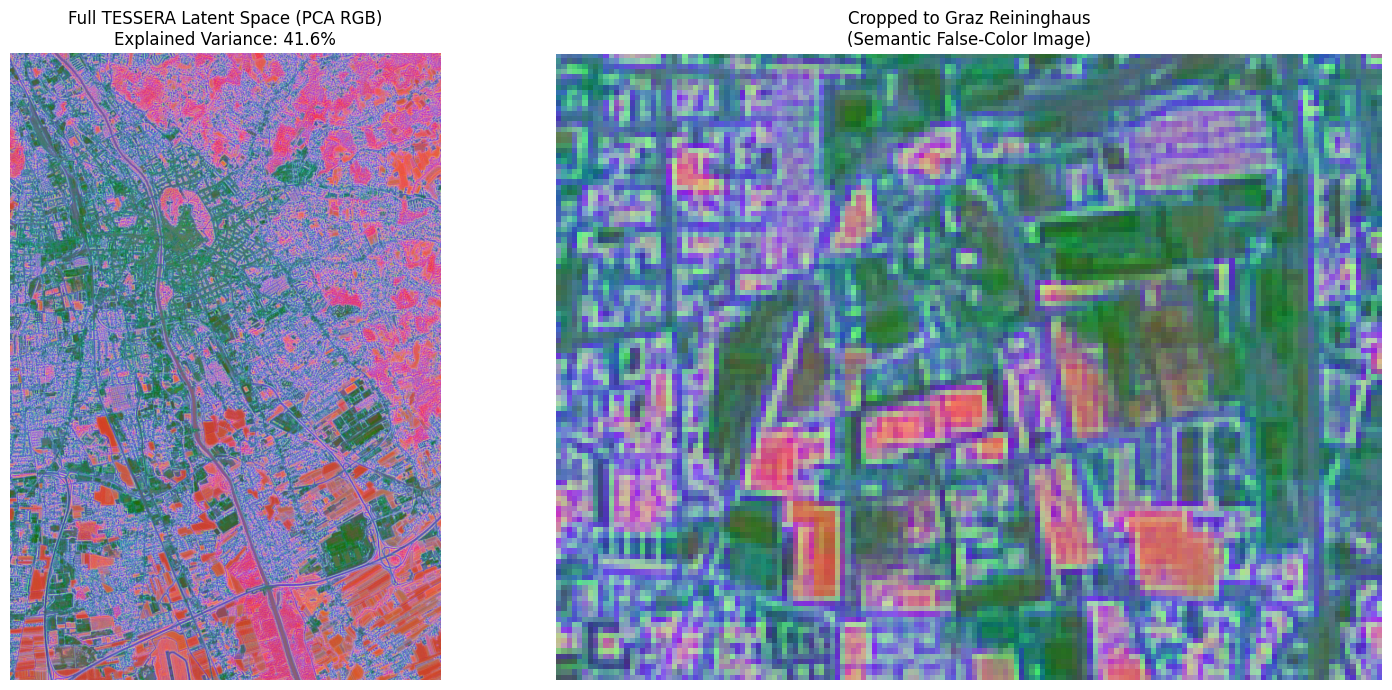

In [31]:
# ==========================================
# BONUS: PCA Latent Space Visualization
# ==========================================

from sklearn.decomposition import PCA

print("Compressing 128 dimensions down to 3 (RGB) using PCA...")

# 1. Prepare the data: Flatten the spatial dimensions (H, W, 128) -> (H*W, 128)
h, w, c = embedding_present.shape
flat_tensor = embedding_present_f32.reshape(-1, c)

# 2. Apply PCA (reduce to 3 principal components)
pca = PCA(n_components=3)
pca_result = pca.fit_transform(flat_tensor)

# 3. Analyze Explained Variance
# How much of the original 128D information is still present in our 3D RGB image?
explained_variance = pca.explained_variance_ratio_
total_variance = np.sum(explained_variance)

print("\n--- PCA Variance Report ---")
print(f"PC1 (Red):   {explained_variance[0]*100:.1f}% of information")
print(f"PC2 (Green): {explained_variance[1]*100:.1f}% of information")
print(f"PC3 (Blue):  {explained_variance[2]*100:.1f}% of information")
print(f"---------------------------")
print(f"Total Information Captured: {total_variance*100:.1f}%\n")

# 4. Reshape and Normalize to [0, 1] so Matplotlib can display it as colors
pca_img = pca_result.reshape(h, w, 3)
pca_img_normalized = np.zeros_like(pca_img)

for i in range(3):
    min_val = pca_img[:, :, i].min()
    max_val = pca_img[:, :, i].max()
    pca_img_normalized[:, :, i] = (pca_img[:, :, i] - min_val) / (max_val - min_val)

# 5. Crop to our Building Area
print("Cropping PCA image to our specific bounding box...")
gdf_buildings_utm = gdf_buildings.to_crs(crs_present)
bounds = gdf_buildings_utm.total_bounds 

# Convert spatial coordinates to pixel rows and columns
row1, col1 = rasterio.transform.rowcol(transform_present, bounds[0], bounds[3])
row2, col2 = rasterio.transform.rowcol(transform_present, bounds[2], bounds[1])

# Safe array slicing (avoids negative scale errors)
row_start, row_end = min(row1, row2), max(row1, row2)
col_start, col_end = min(col1, col2), max(col1, col2)

pca_cropped = pca_img_normalized[row_start:row_end, col_start:col_end, :]

# 6. Plotting the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Full 10x10km Tile
ax1.imshow(pca_img_normalized)
ax1.set_title(f"Full TESSERA Latent Space (PCA RGB)\nExplained Variance: {total_variance*100:.1f}%")
ax1.axis('off')

# Plot 2: Cropped Area
ax2.imshow(pca_cropped)
ax2.set_title(f"Cropped to Graz Reininghaus\n(Semantic False-Color Image)")
ax2.axis('off')

plt.tight_layout()
plt.show()